# Advanced `lilypond` usage

In [1]:
RANDOM_SEED = 42

In [2]:
# load dataset
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True, as_frame=False)
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# use helper methods to get SOM hyperparameter recommendations
from minisom_representation import calc_som_hyparams
print("Recommended SOM parameters:", calc_som_hyparams(X_scaled))
print("Recommended SOM parameters:", calc_som_hyparams(X_scaled, initial_sigma_factor=2.0))
print("Recommended SOM parameters:", calc_som_hyparams(X_scaled, initial_sigma_factor=3.0))

Recommended SOM parameters: {'d1': 7, 'd2': 12, 'sigma': np.float64(6.0)}
Recommended SOM parameters: {'d1': 7, 'd2': 12, 'sigma': np.float64(6.0)}
Recommended SOM parameters: {'d1': 7, 'd2': 12, 'sigma': np.float64(4.0)}


In [4]:
# use `factor=3.0` to get a smaller recommendation for sigma -> `sigma=max(d1, d2)/factor)`
from minisom_representation import calc_initial_sigma
sigma = calc_initial_sigma(7, 12, factor=3.0)
print("Sigma:", sigma)

Sigma: 4.0


Evaluating for epochs of [ 1  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40]...
Training SOM for 1 epochs...
Training SOM for 2 epochs...
Training SOM for 4 epochs...
Training SOM for 6 epochs...
Training SOM for 8 epochs...
Training SOM for 10 epochs...
Training SOM for 12 epochs...
Training SOM for 14 epochs...
Training SOM for 16 epochs...
Training SOM for 18 epochs...
Training SOM for 20 epochs...
Training SOM for 22 epochs...
Training SOM for 24 epochs...
Training SOM for 26 epochs...
Training SOM for 28 epochs...
Training SOM for 30 epochs...
Training SOM for 32 epochs...
Training SOM for 34 epochs...
Training SOM for 36 epochs...
Training SOM for 38 epochs...
Training SOM for 40 epochs...


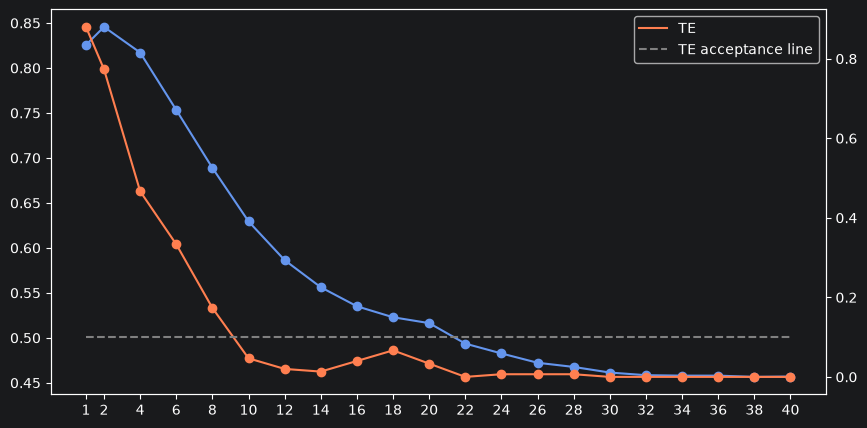


QE (first -> last): 	 0.83 -> 0.46
TE (first -> last): 	 0.88 -> 0.00


In [5]:
# test candidate values for `num_iteration` hyperparameter
from minisom_representation import SomRepresentation, plot_som_convergence_over_epochs
fig, qes, tes = plot_som_convergence_over_epochs(
    SomRepresentation.with_derived_params(X_scaled, random_seed=RANDOM_SEED, verbose=False, sigma=sigma),
    X_scaled,
    te_ceiling=.1,
    epoch_step=2,
    epoch_step_from=2,
    epoch_step_to=40,
    figsize=(10, 5),
    show_fig=True,
    verbose=True
)
print(f"\nQE (first -> last): \t {qes[0]:.2f} -> {qes[-1]:.2f}")
print(f"TE (first -> last): \t {tes[0]:.2f} -> {tes[-1]:.2f}")

In [6]:
# train an SOM representation
epoch = 40
som_representation = SomRepresentation.with_derived_params(X_scaled, random_seed=RANDOM_SEED, verbose=True, sigma=sigma, num_iteration=epoch)
som_representation.fit(X_scaled)


--------------
Based on 150 instances, the recommended SOM hyperparameters are the following:
Total node count (M):	 62
Recommended sides (d1 x d2):	 7 x 12
Initial neighborhood radius (sigma):	 6.0
--------------

 [ 40 / 40 ] 100% - 0:00:00 left Quantization Error: 0.4570

 An SOM representation has been fitted as follows:
------------------------------------------------------- 

Hyperparameters of SOM: 

{'input_len': 4, 'x': 7, 'y': 12, 'sigma': np.float64(4.0), 'topology': 'rectangular', 'learning_rate': 0.5, 'decay_function': 'asymptotic_decay', 'sigma_decay_function': 'asymptotic_decay', 'neighborhood_function': 'gaussian', 'activation_distance': 'euclidean', 'random_seed': 42, 'num_iteration': 40, 'verbose': True} 

Quality of SOM: 

Quantization Error (QE):	0.4569966883099514
Topographic Error (TE): 	0.0


In [7]:
# use the pre-trained SOM representation
from lilypond import Basin
basin = Basin.from_som_representation(som_representation, random_seed=RANDOM_SEED, verbose=False)

In [8]:
basin.pond() \
    .rhizome_layer() \
    .pad_layer() \
    .petal_layer() \
    .visualize();

In [9]:
basin.pond(base_style="iceflock") \
    .rhizome_layer() \
    .pad_layer() \
    .petal_layer() \
    .visualize();

In [10]:
basin.pond() \
    .pad_layer() \
    .attraction_layer(X_scaled) \
    .visualize();


In [11]:
import numpy as np
X_scaled_QE = np.linalg.norm(basin.som_representation.som.quantization(X_scaled) - X_scaled, axis=1)

In [12]:
basin.pond() \
    .pad_layer() \
    .attraction_layer(X_scaled, jitter_amount=.3, marker=dict(opacity=.75, size=10, color=X_scaled_QE, colorscale="Spectral_r", line=dict(width=1, color="black"))) \
    .visualize();

In [13]:
basin.pond(base_style="iceflock") \
    .pad_layer() \
    .attraction_layer(X_scaled, jitter_amount=.3, marker=dict(opacity=.85, size=10, color=X_scaled_QE, colorscale="Spectral_r", line=dict(width=1, color="black"))) \
    .visualize();